In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [5]:
df = pd.read_csv('../data/clean_audio_data.csv')
df.head()

,clue_id,transcript,clue_word_frequency,duration,clue_latency,clue_number_latency,speech_rate,speech_ratio,articulation_rate,pause_count,...,energy_mean,energy_std,energy_range,energy_p25,energy_p75,jitter,shimmer,hnr,confidence,difficulty
0,1,"Okay, let me see here. So, mm-hmm. Alright, t...",0.758687,0.320794,0.910926,0.000000,-0.051565,-0.203309,-0.271700,1.287504,...,-0.334261,0.476862,0.511001,-0.614592,-0.043920,-0.877806,0.759071,0.673909,Neutral,Easy
1,2,homo sapiens to,-2.284780,0.000000,0.000000,0.351803,-0.634625,-1.068199,-0.024220,-0.460494,...,-0.763587,0.627788,-0.349708,-0.614592,-0.929246,1.053497,1.899701,-1.215064,Confident,Easy
2,3,Amendment Now.,0.994141,0.000000,0.000000,0.000000,2.376291,0.441978,2.181183,-0.798816,...,2.096818,-2.601546,-1.518996,-0.614592,1.697958,0.284817,0.306589,0.074622,Confident,Easy
3,4,"This is tough here. Scalpi sensor, 2.",-0.252896,0.000000,0.452498,0.820813,-0.558376,-0.965797,-0.161107,0.159763,...,-0.694616,0.472000,0.149989,-0.614592,-0.878693,1.926226,1.663184,-2.011055,Non-confident,Difficult
4,5,"See, I don't know how to link some of these. ...",-0.261616,0.488518,0.000000,0.000000,0.367425,1.421530,-0.506610,-0.404107,...,0.187358,0.150984,0.007847,1.768796,-0.245707,0.113547,-0.186251,0.036165,Confident,Neutral


In [6]:
df = df.drop(columns=["difficulty"])

## 1. Select Features

Based on the random forest model observations, the following features are going to be dropped:

- MFCCs (too noisy, not interpretable)
- redundant features (highly correlated)

In [7]:
selected_features = [
    "pitch_mean",
    "pitch_p75",
    "jitter",
    "hnr",
    "verbal_hesitation_count",
    "meta_comment_presence",
    "articulation_rate",
    "clue_latency",
    "clue_number_latency",
    "pause_count",
    "pause_max",
    "disfluency",
    "energy_range"
]

In [8]:
X = df[selected_features].copy()
y = df["confidence"] 

In [9]:
# handle missing values
X = X.astype(float)
X = X.fillna(X.mean())

In [11]:
# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # important for class balance
)

In [13]:
# Sanity Check
print(X_train.shape)
print(X_train.isna().sum().sum())
print(y_train.value_counts())

(40, 13)
0
confidence
Confident        20
Non-confident    10
Neutral          10
Name: count, dtype: int64


## 2. Train Logistic Regression & Extract Weights

In [15]:
# train
clf = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [16]:
# inspect coefficients
coef_df = pd.DataFrame(
    clf.coef_.T,
    index=X_train.columns,
    columns=clf.classes_
)
coef_df

,Confident,Neutral,Non-confident
pitch_mean,0.521884,-0.379800,-0.142085
pitch_p75,0.071703,-0.831501,0.759798
jitter,0.310722,-0.853114,0.542392
hnr,0.048198,0.315005,-0.363203
verbal_hesitation_count,-0.228661,0.487717,-0.259056
meta_comment_presence,-0.664377,0.529446,0.134931
articulation_rate,0.136969,0.123956,-0.260925
clue_latency,-0.509244,-0.024503,0.533747
clue_number_latency,-0.275646,-0.173609,0.449255
pause_count,-0.319981,0.229057,0.090924


In [17]:
# make it interpretable
# positive weights signal confidence, negative weights signal non-confidence
confidence_weights = coef_df["Confident"] - coef_df["Non-confident"]
confidence_weights.sort_values(ascending=False)

pitch_mean                 0.663969
hnr                        0.411400
articulation_rate          0.397894
energy_range               0.384237
verbal_hesitation_count    0.030396
jitter                    -0.231671
pause_count               -0.410905
pitch_p75                 -0.688095
clue_number_latency       -0.724901
disfluency                -0.776363
meta_comment_presence     -0.799308
clue_latency              -1.042991
pause_max                 -1.865316
dtype: float64

## 3. Build Confidence Score

In [18]:
weights = confidence_weights.to_dict()

In [19]:
def compute_confidence_score(row, weights):
    score = 0.0
    for feature, w in weights.items():
        score += w * row[feature]
    return score

In [20]:
# compute new score
df["confidence_score"] = X.apply(lambda row: compute_confidence_score(row, weights), axis=1)

<Axes: xlabel='confidence', ylabel='confidence_score'>

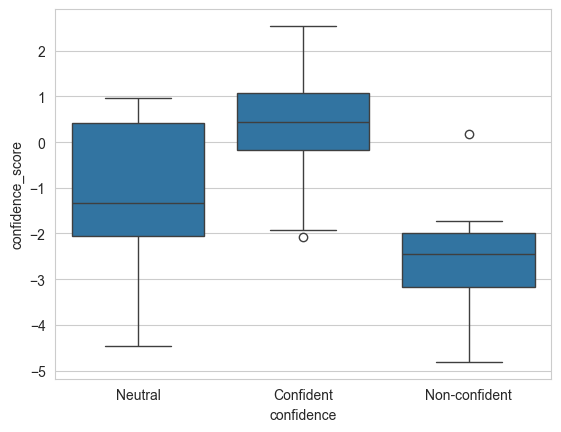

In [22]:
# inspect distribution
sns.boxplot(x=y, y=df["confidence_score"])

## 4. Define Thresholds

In [23]:
# inspect score distribution
df.groupby("confidence")["confidence_score"].describe()

,count,mean,std,min,25%,50%,75%,max
confidence,,,,,,,,
Confident,25.0,0.294698,1.310533,-2.087215,-0.170763,0.430696,1.068853,2.544219
Neutral,13.0,-1.390413,1.776310,-4.473449,-2.049552,-1.323573,0.412657,0.961191
Non-confident,12.0,-2.560926,1.277742,-4.811382,-3.178207,-2.451961,-1.995190,0.184874


In [24]:
# define thresholds:
# below low_thresh → likely non-confident
# above high_thresh → likely confident
low_thresh = df[df["confidence"] == "Non-confident"]["confidence_score"].quantile(0.75)
high_thresh = df[df["confidence"] == "Confident"]["confidence_score"].quantile(0.25)

In [31]:
# decision function
def classify_confidence(score, low, high):
    if score <= low:
        return "Non-confident"
    elif score >= high:
        return "Confident"
    else:
        return "Neutral"

def prediction_strength(score, low, high):
    if score < low:
        return low - score
    elif score > high:
        return score - high
    else:
        return min(score - low, high - score)

In [34]:
df["confidence_pred_rule"] = df["confidence_score"].apply(lambda s: classify_confidence(s, low_thresh, high_thresh))
df["prediction_strength"] = df["confidence_score"].apply(lambda s: prediction_strength(s, low_thresh, high_thresh))

In [35]:
max_strength = df["prediction_strength"].max()
df["strength_norm"] = df["prediction_strength"] / max_strength

One way to use this prediction strength:
```
if strength < 0.1:
    behavior = "very uncertain → be cautious"
elif label == "Confident":
    behavior = "act decisively"
elif label == "Non-confident":
    behavior = "hedge / assist"
else:
    behavior = "neutral / wait"
```

## 5. Evaluation

In [28]:
print(classification_report(df["confidence"], df["confidence_pred_rule"]))

               precision    recall  f1-score   support

    Confident       0.79      0.76      0.78        25
      Neutral       0.42      0.38      0.40        13
Non-confident       0.64      0.75      0.69        12

     accuracy                           0.66        50
    macro avg       0.62      0.63      0.62        50
 weighted avg       0.66      0.66      0.66        50



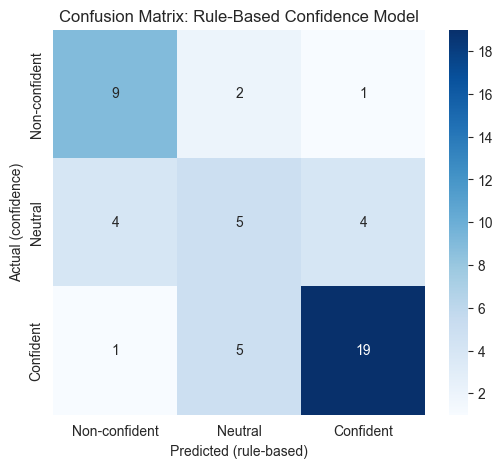

In [30]:
# Ensure same label order
labels = ["Non-confident", "Neutral", "Confident"]

cm = confusion_matrix(df["confidence"], df["confidence_pred_rule"], labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel("Actual (confidence)")
plt.xlabel("Predicted (rule-based)")
plt.title("Confusion Matrix: Rule-Based Confidence Model")
plt.show()

In [41]:
# check correctness
df["correct"] = df["confidence"] == df["confidence_pred_rule"]
df.groupby("correct")["strength_norm"].describe()

,count,mean,std,min,25%,50%,75%,max
correct,,,,,,,,
False,17.0,0.253574,0.242980,0.019303,0.096880,0.207166,0.310301,0.880003
True,33.0,0.352348,0.276024,0.000000,0.164888,0.263233,0.447805,1.000000


<Axes: xlabel='correct', ylabel='strength_norm'>

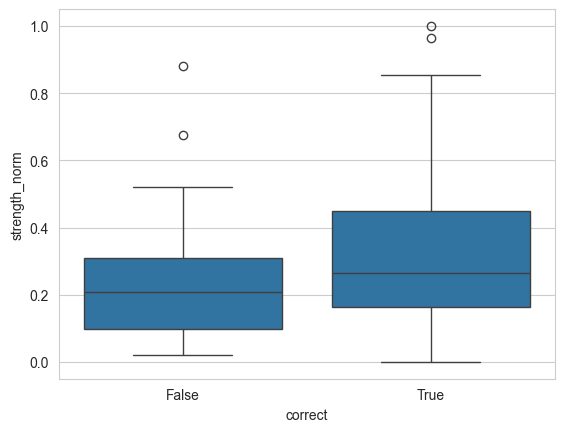

In [42]:
sns.boxplot(x="correct", y="strength_norm", data=df)

In [43]:
df[df["correct"] == False][["confidence", "confidence_pred_rule", "strength_norm"]].sort_values("strength_norm")

,confidence,confidence_pred_rule,strength_norm
8,Neutral,Non-confident,0.019303
36,Confident,Neutral,0.027587
47,Confident,Non-confident,0.032677
22,Non-confident,Neutral,0.039408
13,Confident,Neutral,0.096880
21,Non-confident,Neutral,0.097374
23,Non-confident,Confident,0.126283
18,Confident,Neutral,0.159723
15,Neutral,Confident,0.207166
17,Confident,Neutral,0.231806


## 6. Final Predictions with strength threshold

In [61]:
strength_thresh = 0.25

def final_prediction(row):
    if row["strength_norm"] < strength_thresh:
        return "Uncertain"   # reject low-confidence predictions
    else:
        return row["confidence_pred_rule"]

df["confidence_final"] = df.apply(final_prediction, axis=1)

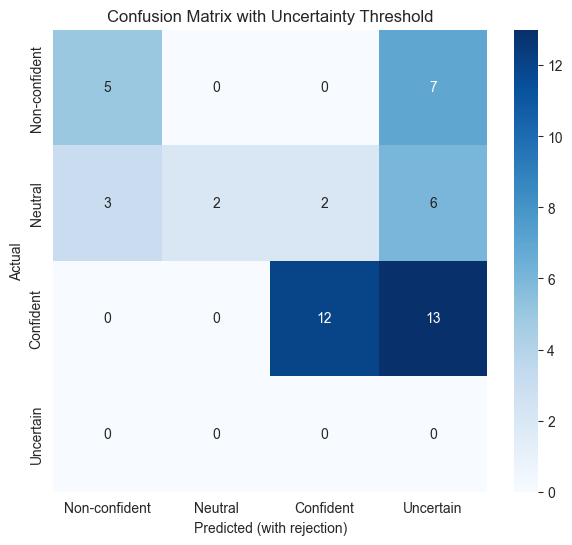

In [62]:
labels = ["Non-confident", "Neutral", "Confident", "Uncertain"]

cm = confusion_matrix(df["confidence"], df["confidence_final"], labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

plt.figure(figsize=(7,6))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.ylabel("Actual")
plt.xlabel("Predicted (with rejection)")
plt.title("Confusion Matrix with Uncertainty Threshold")
plt.show()

In [63]:
# Choosing the best threshold value (0.2, 0.25, 0.3, 0.4): tradeoff between accuracy & coverage
# Important: reliable robot behavior
threshold = 0.25

kept = df[df["strength_norm"] >= threshold]
accuracy = (kept["correct"]).mean()
coverage = len(kept) / len(df)

print("Accuracy:", accuracy)
print("Coverage:", coverage)

Accuracy: 0.7916666666666666
Coverage: 0.48
